In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np      
from scipy.integrate import complex_ode

from tasks import make_static_sin_task
from encoding_masking import build_masked_input, compute_tdm_params
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse
from Reservoirs.LangKobayashi import expand_virtual_nodes, simulate_lk, simulate_lk_mini, extract_R_from_E, intensities_after_theta_times, charge_at_theta_intervals
from MC_test import linear_memory_curve, plot_memory_curve

In [2]:
# #sweeped params
# mask_types = ["binary", "continuous", "m_sequence", "two_sine"]
# eta_sweep = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]
# mask_seeds = [0, 1, 2, 3, 4]
# ridge_sweep = [0,1e-10,1e-8,1e-6,1e-4,1e-2]

In [3]:
#constant paramters

eta = 0.001
ridge_alpha = 1e-8
N = 50 
mask_type = "m_sequence"

TLk = 150
kappa = 0.1  
alpha = 0 
phi = 0 
xi = 0 
D_noise = 10**-7*0
p= 0.05
dt = 0.1 #ONLY VARY AT THE VERY END
theta = 22
tau_factor = 1.41 

washout = 200
#L = 500 + washout #ONLY VARY AT THE VERY END
task_seed = 0
order = 10 #narma order
split = 0.8 # test/predict split

In [4]:
TDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop 
Nd_delay = TDM_parameters.Nd_delay    
tau = TDM_parameters.tau
print(TDM_parameters)

TDMParams(N=50, theta=22, dt=0.1, T=1100, tau=1551.0, Nd_loop=11000, Nd_delay=15510, tap_stride=220)


In [5]:
L = 1000 
rng = np.random.default_rng(0)
u = rng.uniform(-1.0, 1.0, size=L) #input

In [6]:
x_norm, mask, V = build_masked_input(u, N=N, rng=1, mask_type= mask_type)
Vs = expand_virtual_nodes(V, tap_stride, Nd_loop)

In [7]:
E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, xi=xi, Tlk=TLk, E0=1e-3+0j, n0=0.0)

In [8]:
R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop, washout_cycles = washout)

In [9]:
u = u[washout:]
delays, capacities, nrmse, MC_est = linear_memory_curve(R, u, max_delay=80, washout=0, split=split, ridge_alpha=ridge_alpha)


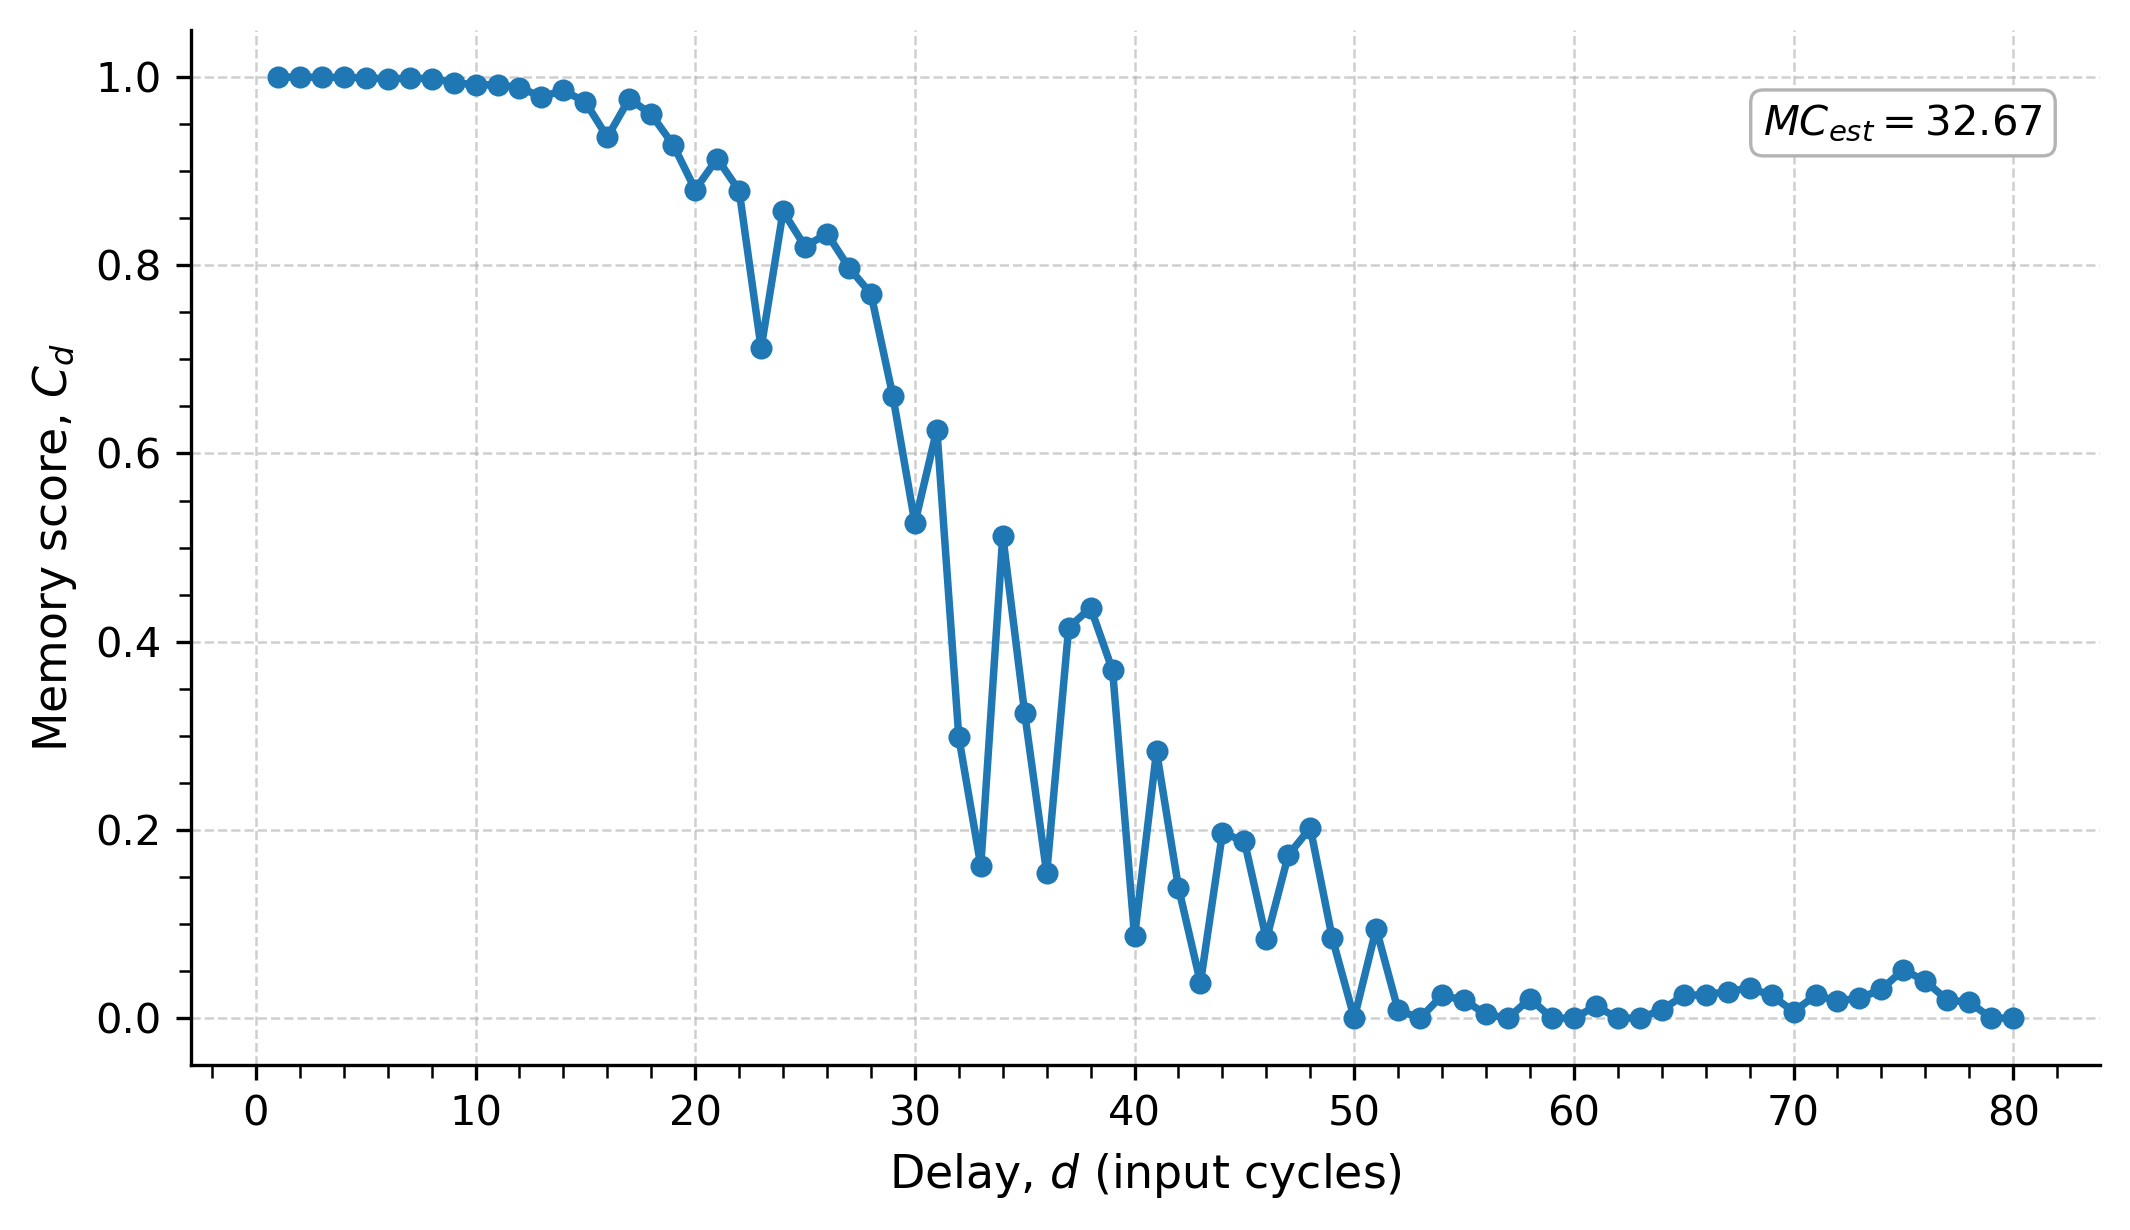

Estimated linear MC: 32.67361257034662


In [10]:
fig1, ax =plot_memory_curve(delays, capacities, MC_est)

print("Estimated linear MC:", MC_est)

In [11]:
fig1.savefig(
    "N50_msequence_MC.png",
    dpi=300,
    bbox_inches="tight"
)
